# Hybrid Knowledge Base Integration & Evaluation

This notebook integrates the trained CNN models with a clinical knowledge base to produce
explainable triage decisions for Diabetic Retinopathy screening.

**Pipeline:**
1. Load both trained ResNet-50 models (Method 1: multi-class, Method 2: hierarchical)
2. Run inference on the held-out test set
3. Fuse CNN predictions with patient clinical metadata via a rule-based triage engine
4. Evaluate and compare the hybrid outputs

**Category 3: Hybrid Approaches** — Knowledge Representation + Machine Learning

## 1. Setup & Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import warnings

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    balanced_accuracy_score
)
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Configuration

In [24]:
CONFIG = {
    'data_dir': os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split'),
    'cache_dir': os.path.join('..', 'dataset', 'Dataset-02', 'dataset_split_cache256'),
    'img_size': 224,
    'batch_size': 64,
    'num_workers': 0,
    'use_amp': True,
    'method1_model_path': 'models//best_method1_multiclass_resnet50.pth',
    'method2_binary_path': 'models/best_method2_binary_resnet50.pth',
    'method2_severity_path': 'models/best_method2_severity_resnet50.pth',
}

DR_LABELS = {0: 'No DR', 1: 'Mild NPDR', 2: 'Moderate NPDR', 3: 'Severe NPDR', 4: 'PDR'}
AMP_ENABLED = CONFIG['use_amp'] and torch.cuda.is_available()

## 3. Load Test Data

In [25]:
test_csv = os.path.join(CONFIG['data_dir'], 'test', 'test.csv')
test_df = pd.read_csv(test_csv)
print(f'Test set: {len(test_df)} images')
print(f'\nDR_ICDR distribution:')
for grade in range(5):
    count = (test_df['DR_ICDR'] == grade).sum()
    print(f'  Grade {grade} ({DR_LABELS[grade]:>15}): {count:>5} ({count/len(test_df)*100:.1f}%)')

Test set: 1619 images

DR_ICDR distribution:
  Grade 0 (          No DR):  1488 (91.9%)
  Grade 1 (      Mild NPDR):    23 (1.4%)
  Grade 2 (  Moderate NPDR):    50 (3.1%)
  Grade 3 (    Severe NPDR):     6 (0.4%)
  Grade 4 (            PDR):    52 (3.2%)


## 4. Dataset & Model Utilities

In [26]:
class DRDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{row['image_id']}.jpg")
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = int(row['DR_ICDR'])
        return image, label


def build_resnet50(num_classes):
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(model.fc.in_features, num_classes)
    )
    return model


test_transforms = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Use the 256px cache built by training notebooks
test_img_dir = os.path.join(CONFIG['cache_dir'], 'test', 'images')
test_dataset = DRDataset(test_df, test_img_dir, test_transforms)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=CONFIG['num_workers'],
                         pin_memory=True)

print(f'Test loader: {len(test_loader)} batches of {CONFIG["batch_size"]}')

Test loader: 26 batches of 64


## 5. Load Trained Models

In [27]:
# Method 1: Single 5-class model
model_m1 = build_resnet50(num_classes=5).to(device)
model_m1.load_state_dict(torch.load(CONFIG['method1_model_path'], map_location=device))
model_m1.eval()
print(f'Method 1 model loaded from {CONFIG["method1_model_path"]}')

# Method 2: Binary + Severity
model_m2_binary = build_resnet50(num_classes=2).to(device)
model_m2_binary.load_state_dict(torch.load(CONFIG['method2_binary_path'], map_location=device))
model_m2_binary.eval()
print(f'Method 2 binary model loaded from {CONFIG["method2_binary_path"]}')

model_m2_severity = build_resnet50(num_classes=4).to(device)
model_m2_severity.load_state_dict(torch.load(CONFIG['method2_severity_path'], map_location=device))
model_m2_severity.eval()
print(f'Method 2 severity model loaded from {CONFIG["method2_severity_path"]}')

Method 1 model loaded from models//best_method1_multiclass_resnet50.pth
Method 2 binary model loaded from models/best_method2_binary_resnet50.pth
Method 2 severity model loaded from models/best_method2_severity_resnet50.pth


## 6. Run CNN Inference on Test Set

In [6]:
m1_preds = []
m2_preds = []
true_labels = []

with torch.no_grad(), torch.amp.autocast('cuda', enabled=AMP_ENABLED):
    for images, labels in tqdm(test_loader, desc='Running inference'):
        images = images.to(device, non_blocking=True)

        # Method 1: direct 5-class
        m1_out = model_m1(images)
        m1_preds.extend(m1_out.argmax(1).cpu().numpy())

        # Method 2: binary -> severity pipeline
        bin_out = model_m2_binary(images)
        bin_pred = bin_out.argmax(1)
        batch_pred = torch.zeros_like(bin_pred)
        mal_mask = bin_pred == 1
        if mal_mask.any():
            sev_out = model_m2_severity(images[mal_mask])
            batch_pred[mal_mask] = sev_out.argmax(1) + 1
        m2_preds.extend(batch_pred.cpu().numpy())

        true_labels.extend(labels.numpy())

m1_preds = np.array(m1_preds)
m2_preds = np.array(m2_preds)
true_labels = np.array(true_labels)

print(f'\nInference complete: {len(true_labels)} images')

Running inference: 100%|██████████| 26/26 [00:14<00:00,  1.79it/s]


Inference complete: 1619 images


## 7. CNN-Only Classification Metrics (Baseline)

In [7]:
target_names = [f'Grade {i} ({DR_LABELS[i]})' for i in range(5)]

print('=' * 65)
print('METHOD 1 — Multi-Class ResNet-50 (CNN Only)')
print('=' * 65)
print(f'Accuracy:          {(m1_preds == true_labels).mean():.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(true_labels, m1_preds):.4f}')
print(f'F1 (weighted):     {f1_score(true_labels, m1_preds, average="weighted"):.4f}')
print(f'F1 (macro):        {f1_score(true_labels, m1_preds, average="macro"):.4f}')
print()
print(classification_report(true_labels, m1_preds, target_names=target_names, zero_division=0))

print('\n' + '=' * 65)
print('METHOD 2 — Hierarchical Binary + Severity (CNN Only)')
print('=' * 65)
print(f'Accuracy:          {(m2_preds == true_labels).mean():.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(true_labels, m2_preds):.4f}')
print(f'F1 (weighted):     {f1_score(true_labels, m2_preds, average="weighted"):.4f}')
print(f'F1 (macro):        {f1_score(true_labels, m2_preds, average="macro"):.4f}')
print()
print(classification_report(true_labels, m2_preds, target_names=target_names, zero_division=0))

METHOD 1 — Multi-Class ResNet-50 (CNN Only)
Accuracy:          0.9351
Balanced Accuracy: 0.6064
F1 (weighted):     0.9385
F1 (macro):        0.5610

                         precision    recall  f1-score   support

        Grade 0 (No DR)       0.98      0.97      0.97      1488
    Grade 1 (Mild NPDR)       0.25      0.39      0.31        23
Grade 2 (Moderate NPDR)       0.49      0.46      0.47        50
  Grade 3 (Severe NPDR)       0.27      0.50      0.35         6
          Grade 4 (PDR)       0.69      0.71      0.70        52

               accuracy                           0.94      1619
              macro avg       0.54      0.61      0.56      1619
           weighted avg       0.94      0.94      0.94      1619


METHOD 2 — Hierarchical Binary + Severity (CNN Only)
Accuracy:          0.9469
Balanced Accuracy: 0.5957
F1 (weighted):     0.9459
F1 (macro):        0.5785

                         precision    recall  f1-score   support

        Grade 0 (No DR)       0.98    

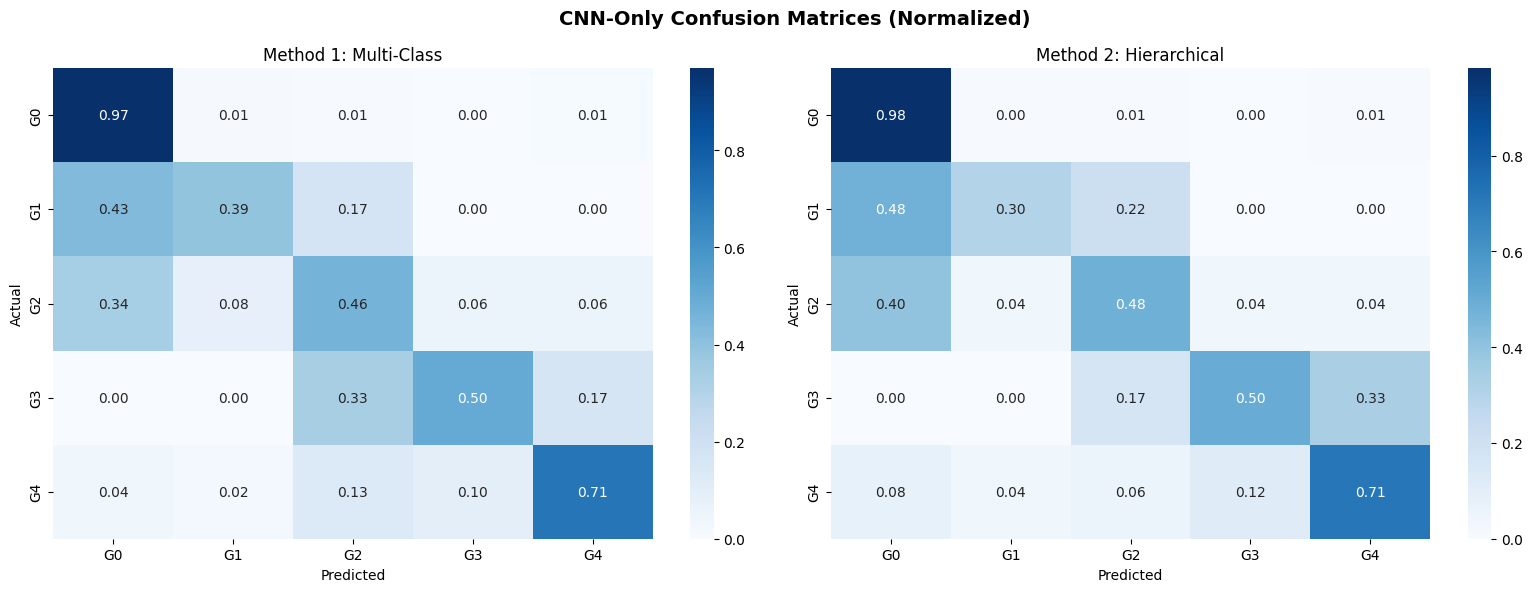

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, title in [(axes[0], m1_preds, 'Method 1: Multi-Class'),
                          (axes[1], m2_preds, 'Method 2: Hierarchical')]:
    cm = confusion_matrix(true_labels, preds, labels=range(5))
    cm_norm = cm.astype('float') / (cm.sum(axis=1, keepdims=True) + 1e-8)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=[f'G{i}' for i in range(5)],
                yticklabels=[f'G{i}' for i in range(5)])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.suptitle('CNN-Only Confusion Matrices (Normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hybrid_cnn_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Knowledge Base Integration
---

## 8. Clinical Knowledge Base — Tabular Risk Scoring Engine

The triage engine computes a systemic risk level (HIGH / MODERATE / LOW) from the patient's
clinical metadata, then fuses it with the CNN's image grade to produce a triage action.

In [9]:
class DiabeticRetinopathyTriageEngine:
    """
    Hybrid Knowledge Base: fuses CNN image grading with structured
    clinical metadata to produce explainable triage decisions.
    """

    def calculate_tabular_risk(self, age, duration, uses_insulin,
                               has_hypertension, has_dyslipidemia,
                               has_kidney_disease, on_dialysis):
        if has_kidney_disease or on_dialysis:
            return 'HIGH'
        if duration > 15.5:
            return 'HIGH'
        if duration > 11.5 and uses_insulin and age > 18.5:
            return 'HIGH'
        if has_hypertension and has_dyslipidemia and uses_insulin:
            return 'HIGH'
        if has_hypertension or has_dyslipidemia:
            return 'MODERATE'
        if duration > 5.5 and uses_insulin and age > 18.5:
            return 'MODERATE'
        return 'LOW'

    def evaluate_triage(self, cnn_grade, macular_edema, quality,
                        age, duration, uses_insulin,
                        has_hypertension, has_dyslipidemia,
                        has_kidney_disease, on_dialysis):
        if str(quality).lower() == 'inadequate':
            return {
                'action': 'RETAKE IMAGE',
                'urgency_level': 0,
                'tabular_risk': 'N/A',
                'rationale': 'Image quality inadequate for reliable classification.'
            }

        tabular_risk = self.calculate_tabular_risk(
            age, duration, uses_insulin,
            has_hypertension, has_dyslipidemia,
            has_kidney_disease, on_dialysis
        )

        if cnn_grade >= 3 or macular_edema:
            return {
                'action': 'URGENT REFERRAL',
                'urgency_level': 3,
                'tabular_risk': tabular_risk,
                'rationale': f'Critical damage detected (Grade {cnn_grade}' +
                             (' + Macular Edema' if macular_edema else '') +
                             '). Immediate specialist intervention required.'
            }

        if cnn_grade == 2:
            if tabular_risk == 'HIGH':
                return {
                    'action': 'PRIORITY REFERRAL',
                    'urgency_level': 2,
                    'tabular_risk': tabular_risk,
                    'rationale': 'Moderate DR aggravated by high systemic risk. Escalated priority.'
                }
            return {
                'action': 'ROUTINE REFERRAL',
                'urgency_level': 1,
                'tabular_risk': tabular_risk,
                'rationale': 'Moderate DR detected. Standard specialist evaluation needed.'
            }

        if cnn_grade == 1:
            if tabular_risk == 'HIGH':
                return {
                    'action': 'ROUTINE REFERRAL',
                    'urgency_level': 1,
                    'tabular_risk': tabular_risk,
                    'rationale': 'Mild DR with high systemic risk — proactive specialist review needed.'
                }
            if tabular_risk == 'MODERATE':
                return {
                    'action': 'LOCAL MONITORING',
                    'urgency_level': 1,
                    'tabular_risk': tabular_risk,
                    'rationale': 'Mild DR aggravated by cardiovascular risk factors. 6-month follow-up.'
                }
            return {
                'action': 'LOCAL MONITORING',
                'urgency_level': 0,
                'tabular_risk': tabular_risk,
                'rationale': 'Mild DR in a well-controlled patient. 12-month follow-up.'
            }

        # Grade 0
        if tabular_risk == 'HIGH':
            return {
                'action': 'VIGILANCE SCREENING',
                'urgency_level': 0,
                'tabular_risk': tabular_risk,
                'rationale': 'Retina healthy but systemic risk is high — 6-month screening recommended.'
            }
        return {
            'action': 'ANNUAL SCREENING',
            'urgency_level': 0,
            'tabular_risk': tabular_risk,
            'rationale': 'Retina healthy, systemic health stable. Standard yearly checkup.'
        }

triage_engine = DiabeticRetinopathyTriageEngine()
print('Triage engine initialised.')

Triage engine initialised.


## 9. Extract Clinical Features from Test CSV

In [10]:
def extract_clinical_features(df):
    """Parse raw CSV columns into the features the triage engine expects."""
    features = pd.DataFrame(index=df.index)

    features['age'] = pd.to_numeric(df['patient_age'], errors='coerce').fillna(50.0)

    features['duration'] = pd.to_numeric(df['diabetes_time_y'], errors='coerce').fillna(0.0)

    features['uses_insulin'] = df['insuline'].apply(
        lambda x: str(x).strip().lower() == 'yes')

    comorbidities = df['comorbidities'].fillna('').str.lower()
    features['has_hypertension'] = (
        comorbidities.str.contains('hypertension', na=False) |
        (df['hypertensive_retinopathy'] == 1)
    )

    features['has_dyslipidemia'] = comorbidities.str.contains(
        'dyslipidemia|hypercholesterolemia|hyperlipidemia', na=False)

    features['has_kidney_disease'] = comorbidities.str.contains(
        'kidney|renal|nephro', na=False)

    features['on_dialysis'] = comorbidities.str.contains('dialysis', na=False)

    features['quality'] = df['quality']
    features['macular_edema'] = df['macular_edema'] == 1

    return features


clinical = extract_clinical_features(test_df)
print(f'Clinical features extracted for {len(clinical)} test patients')
print(f'\nFeature summary:')
print(f'  Age — mean: {clinical["age"].mean():.1f}, missing filled with 50')
print(f'  Duration — mean: {clinical["duration"].mean():.1f} yrs')
print(f'  Insulin users: {clinical["uses_insulin"].sum()}')
print(f'  Hypertension: {clinical["has_hypertension"].sum()}')
print(f'  Dyslipidemia: {clinical["has_dyslipidemia"].sum()}')
print(f'  Kidney disease: {clinical["has_kidney_disease"].sum()}')
print(f'  Macular edema: {clinical["macular_edema"].sum()}')
print(f'  Inadequate quality: {(clinical["quality"] == "Inadequate").sum()}')

Clinical features extracted for 1619 test patients

Feature summary:
  Age — mean: 54.6, missing filled with 50
  Duration — mean: 1.8 yrs
  Insulin users: 98
  Hypertension: 342
  Dyslipidemia: 19
  Kidney disease: 4
  Macular edema: 51
  Inadequate quality: 192


## 10. Run Hybrid Triage on Entire Test Set

In [11]:
def run_hybrid_triage(cnn_predictions, clinical_df, engine):
    """Run triage engine for every test patient. Returns a DataFrame of decisions."""
    results = []
    for i in range(len(cnn_predictions)):
        row = clinical_df.iloc[i]
        decision = engine.evaluate_triage(
            cnn_grade=int(cnn_predictions[i]),
            macular_edema=bool(row['macular_edema']),
            quality=row['quality'],
            age=float(row['age']),
            duration=float(row['duration']),
            uses_insulin=bool(row['uses_insulin']),
            has_hypertension=bool(row['has_hypertension']),
            has_dyslipidemia=bool(row['has_dyslipidemia']),
            has_kidney_disease=bool(row['has_kidney_disease']),
            on_dialysis=bool(row['on_dialysis'])
        )
        results.append(decision)
    return pd.DataFrame(results)


# Run triage for both methods
triage_m1 = run_hybrid_triage(m1_preds, clinical, triage_engine)
triage_m2 = run_hybrid_triage(m2_preds, clinical, triage_engine)

# Also run with ground-truth grades as a reference
triage_gt = run_hybrid_triage(true_labels, clinical, triage_engine)

print('Hybrid triage complete for all three sources (Method 1, Method 2, Ground Truth).')

Hybrid triage complete for all three sources (Method 1, Method 2, Ground Truth).


## 11. Triage Action Distribution

In [12]:
ACTION_ORDER = [
    'ANNUAL SCREENING', 'VIGILANCE SCREENING', 'LOCAL MONITORING',
    'ROUTINE REFERRAL', 'PRIORITY REFERRAL', 'URGENT REFERRAL', 'RETAKE IMAGE'
]

def action_counts(triage_df, label):
    counts = triage_df['action'].value_counts()
    row = {a: counts.get(a, 0) for a in ACTION_ORDER}
    row['Source'] = label
    return row

dist_df = pd.DataFrame([
    action_counts(triage_gt, 'Ground Truth'),
    action_counts(triage_m1, 'Method 1 (Multi-Class)'),
    action_counts(triage_m2, 'Method 2 (Hierarchical)'),
]).set_index('Source')

print('=== Triage Action Distribution ===')
print(dist_df.to_string())

=== Triage Action Distribution ===
                         ANNUAL SCREENING  VIGILANCE SCREENING  LOCAL MONITORING  ROUTINE REFERRAL  PRIORITY REFERRAL  URGENT REFERRAL  RETAKE IMAGE
Source                                                                                                                                              
Ground Truth                         1267                   33                 9                32                  8               78           192
Method 1 (Multi-Class)               1250                   32                22                28                  7               88           192
Method 2 (Hierarchical)              1271                   39                 9                18                  8               82           192


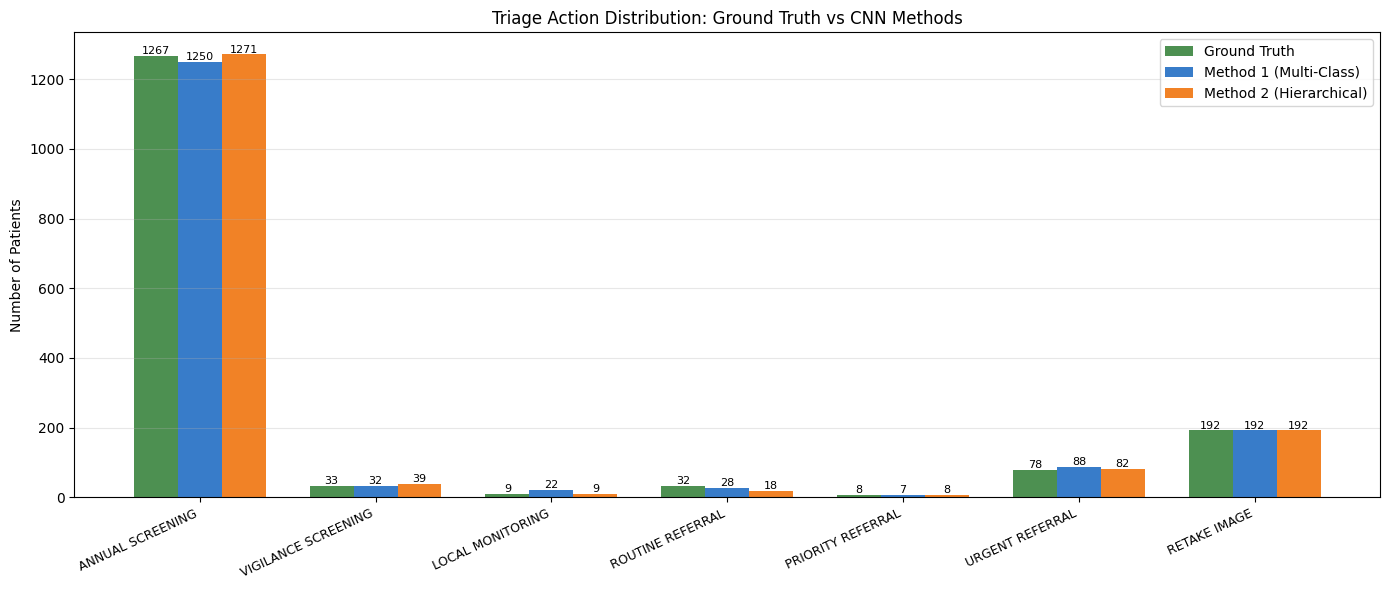

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
plot_actions = [a for a in ACTION_ORDER if dist_df[a].sum() > 0]
x = np.arange(len(plot_actions))
width = 0.25

colors = ['#2e7d32', '#1565c0', '#ef6c00']
for i, (label, color) in enumerate(zip(dist_df.index, colors)):
    values = [dist_df.loc[label, a] for a in plot_actions]
    bars = ax.bar(x + i * width, values, width, label=label, color=color, alpha=0.85)
    for bar, val in zip(bars, values):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    str(val), ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(plot_actions, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Number of Patients')
ax.set_title('Triage Action Distribution: Ground Truth vs CNN Methods')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_triage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Tabular Risk Profile of Test Population

=== Tabular Risk Distribution (Test Set) ===
        HIGH:    81 (5.0%)
    MODERATE:   299 (18.5%)
         LOW:  1047 (64.7%)
         N/A:   192 (11.9%)


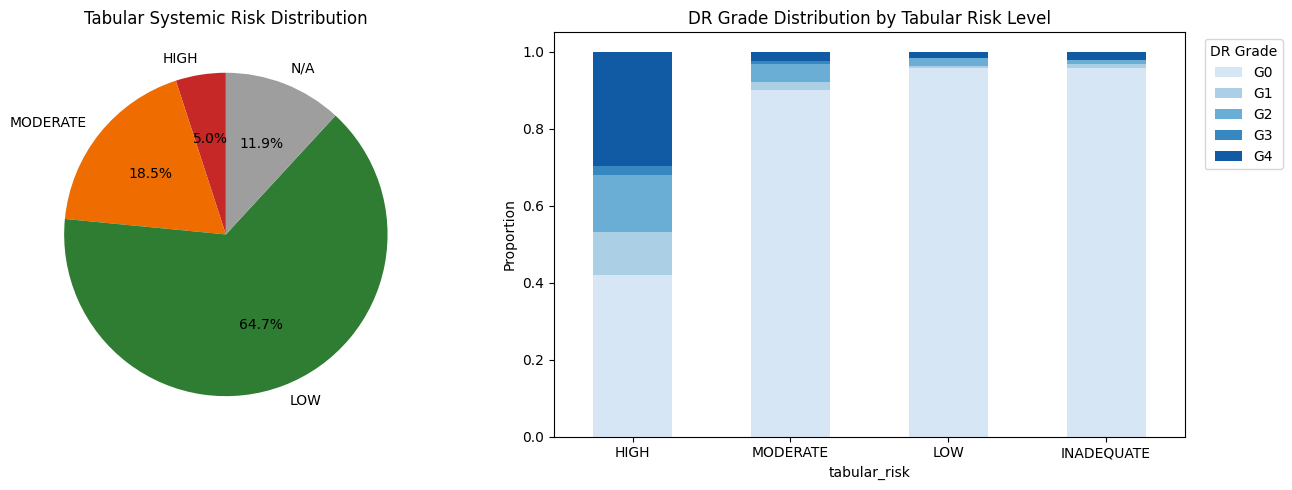

In [14]:
# Show the tabular risk distribution (independent of CNN)
risk_counts = triage_gt['tabular_risk'].value_counts()
print('=== Tabular Risk Distribution (Test Set) ===')
for risk in ['HIGH', 'MODERATE', 'LOW', 'N/A']:
    count = risk_counts.get(risk, 0)
    print(f'  {risk:>10}: {count:>5} ({count/len(triage_gt)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Risk distribution pie
risk_vals = [risk_counts.get(r, 0) for r in ['HIGH', 'MODERATE', 'LOW', 'N/A'] if risk_counts.get(r, 0) > 0]
risk_labels = [r for r in ['HIGH', 'MODERATE', 'LOW', 'N/A'] if risk_counts.get(r, 0) > 0]
risk_colors = {'HIGH': '#c62828', 'MODERATE': '#ef6c00', 'LOW': '#2e7d32', 'N/A': '#9e9e9e'}
axes[0].pie(risk_vals, labels=risk_labels, autopct='%1.1f%%',
            colors=[risk_colors[r] for r in risk_labels], startangle=90)
axes[0].set_title('Tabular Systemic Risk Distribution')

# Risk vs actual DR grade
risk_grade = pd.crosstab(
    triage_gt['tabular_risk'].replace('N/A', 'INADEQUATE'),
    test_df['DR_ICDR'].map(lambda g: f'G{g}'),
    normalize='index'
)
risk_grade = risk_grade.reindex(index=['HIGH', 'MODERATE', 'LOW', 'INADEQUATE'],
                                 columns=[f'G{i}' for i in range(5)])
risk_grade.dropna(how='all', inplace=True)
risk_grade.plot(kind='bar', stacked=True, ax=axes[1],
                color=sns.color_palette('Blues', 5))
axes[1].set_ylabel('Proportion')
axes[1].set_title('DR Grade Distribution by Tabular Risk Level')
axes[1].legend(title='DR Grade', bbox_to_anchor=(1.02, 1))
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('hybrid_risk_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Triage Concordance — How Often Do the Methods Agree?

In [15]:
# Concordance with ground-truth triage
m1_match = (triage_m1['action'] == triage_gt['action']).mean()
m2_match = (triage_m2['action'] == triage_gt['action']).mean()
m1_m2_match = (triage_m1['action'] == triage_m2['action']).mean()

print('=== Triage Action Concordance ===')
print(f'  Method 1 vs Ground Truth: {m1_match:.4f} ({m1_match*100:.1f}%)')
print(f'  Method 2 vs Ground Truth: {m2_match:.4f} ({m2_match*100:.1f}%)')
print(f'  Method 1 vs Method 2:     {m1_m2_match:.4f} ({m1_m2_match*100:.1f}%)')

# Urgency-level concordance (coarser — did the urgency bucket match?)
m1_urg_match = (triage_m1['urgency_level'] == triage_gt['urgency_level']).mean()
m2_urg_match = (triage_m2['urgency_level'] == triage_gt['urgency_level']).mean()
print(f'\n=== Urgency Level Concordance ===')
print(f'  Method 1 vs Ground Truth: {m1_urg_match:.4f} ({m1_urg_match*100:.1f}%)')
print(f'  Method 2 vs Ground Truth: {m2_urg_match:.4f} ({m2_urg_match*100:.1f}%)')

=== Triage Action Concordance ===
  Method 1 vs Ground Truth: 0.9531 (95.3%)
  Method 2 vs Ground Truth: 0.9617 (96.2%)
  Method 1 vs Method 2:     0.9685 (96.8%)

=== Urgency Level Concordance ===
  Method 1 vs Ground Truth: 0.9629 (96.3%)
  Method 2 vs Ground Truth: 0.9666 (96.7%)


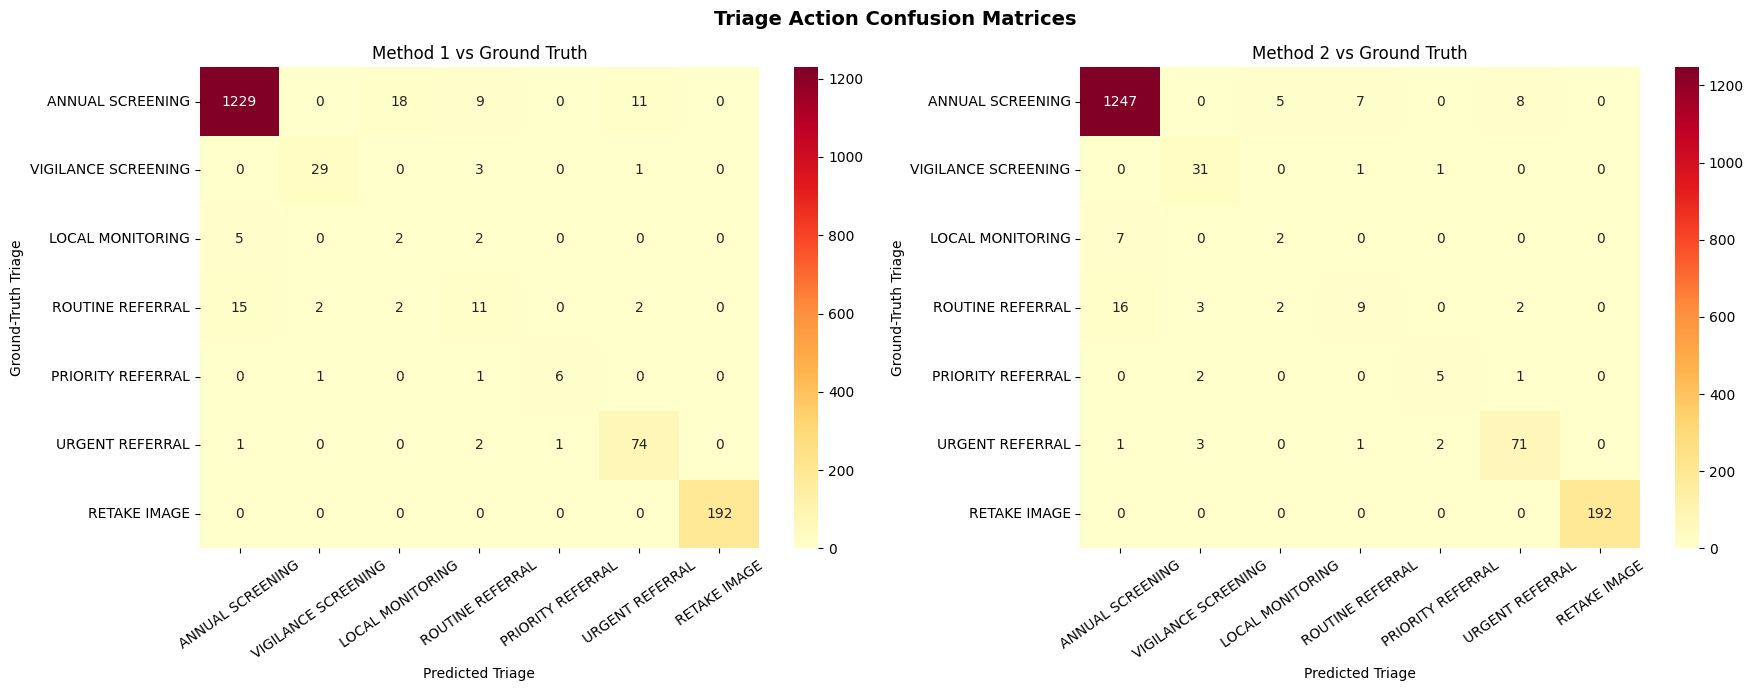

In [16]:
# Confusion matrix of triage actions: Method 1 vs Ground Truth
valid_actions = [a for a in ACTION_ORDER if a in triage_gt['action'].values or a in triage_m1['action'].values]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, triage_pred, title in [(axes[0], triage_m1, 'Method 1 vs Ground Truth'),
                                (axes[1], triage_m2, 'Method 2 vs Ground Truth')]:
    cm = confusion_matrix(triage_gt['action'], triage_pred['action'], labels=valid_actions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                xticklabels=valid_actions, yticklabels=valid_actions)
    ax.set_xlabel('Predicted Triage')
    ax.set_ylabel('Ground-Truth Triage')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Triage Action Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hybrid_triage_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Clinical Safety Analysis — Under-Triage & Over-Triage

In [17]:
def safety_analysis(pred_triage, gt_triage, method_name):
    """Compare urgency levels: under-triage is dangerous, over-triage is wasteful."""
    pred_urg = pred_triage['urgency_level'].values
    gt_urg = gt_triage['urgency_level'].values

    correct = (pred_urg == gt_urg).sum()
    under = (pred_urg < gt_urg).sum()   # predicted less urgent than reality
    over = (pred_urg > gt_urg).sum()    # predicted more urgent than reality
    total = len(pred_urg)

    print(f'\n{method_name}:')
    print(f'  Correct urgency:   {correct:>5} ({correct/total*100:.1f}%)')
    print(f'  Under-triage:      {under:>5} ({under/total*100:.1f}%) — DANGEROUS (missed urgency)')
    print(f'  Over-triage:       {over:>5} ({over/total*100:.1f}%) — wasteful but safe')
    return {'method': method_name, 'correct': correct, 'under': under, 'over': over, 'total': total}

print('=' * 60)
print('CLINICAL SAFETY ANALYSIS')
print('=' * 60)

s1 = safety_analysis(triage_m1, triage_gt, 'Method 1 (Multi-Class)')
s2 = safety_analysis(triage_m2, triage_gt, 'Method 2 (Hierarchical)')

CLINICAL SAFETY ANALYSIS

Method 1 (Multi-Class):
  Correct urgency:    1559 (96.3%)
  Under-triage:         26 (1.6%) — DANGEROUS (missed urgency)
  Over-triage:          34 (2.1%) — wasteful but safe

Method 2 (Hierarchical):
  Correct urgency:    1565 (96.7%)
  Under-triage:         32 (2.0%) — DANGEROUS (missed urgency)
  Over-triage:          22 (1.4%) — wasteful but safe


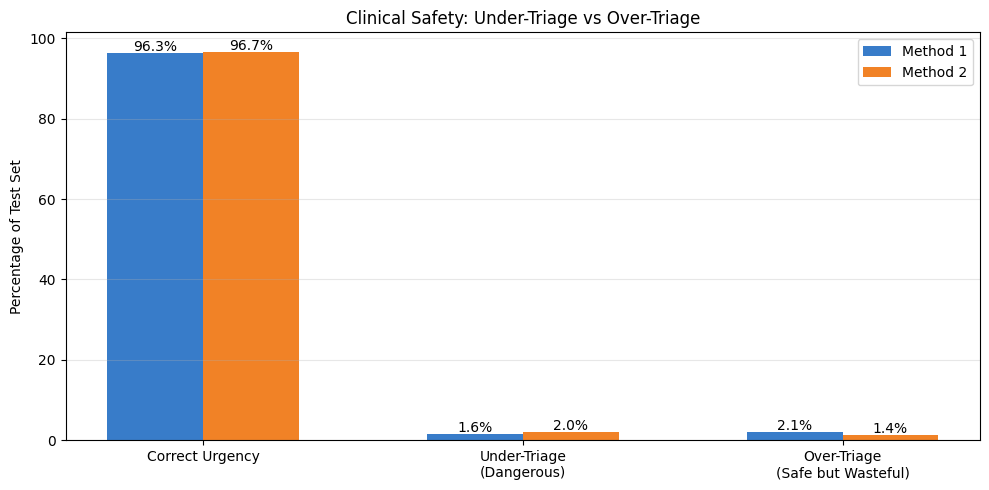

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

categories = ['Correct Urgency', 'Under-Triage\n(Dangerous)', 'Over-Triage\n(Safe but Wasteful)']
m1_vals = [s1['correct']/s1['total']*100, s1['under']/s1['total']*100, s1['over']/s1['total']*100]
m2_vals = [s2['correct']/s2['total']*100, s2['under']/s2['total']*100, s2['over']/s2['total']*100]

x = np.arange(len(categories))
width = 0.3
bars1 = ax.bar(x - width/2, m1_vals, width, label='Method 1', color='#1565c0', alpha=0.85)
bars2 = ax.bar(x + width/2, m2_vals, width, label='Method 2', color='#ef6c00', alpha=0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10)

ax.set_ylabel('Percentage of Test Set')
ax.set_title('Clinical Safety: Under-Triage vs Over-Triage')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('hybrid_safety_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Knowledge Base Impact — Cases Where Tabular Risk Changed the Outcome

In [19]:
def kb_impact_analysis(cnn_preds, triage_df, method_name):
    """Find cases where the KB elevated or retained the triage action
    beyond what a pure CNN grade alone would have produced."""
    # A pure CNN (no KB) would map: G0->ANNUAL, G1->LOCAL, G2->ROUTINE, G3/4->URGENT
    cnn_only_action = []
    for g in cnn_preds:
        if g == 0: cnn_only_action.append('ANNUAL SCREENING')
        elif g == 1: cnn_only_action.append('LOCAL MONITORING')
        elif g == 2: cnn_only_action.append('ROUTINE REFERRAL')
        else: cnn_only_action.append('URGENT REFERRAL')

    elevated = 0
    retake_flagged = 0
    macular_escalated = 0

    for i in range(len(cnn_preds)):
        hybrid_action = triage_df.iloc[i]['action']
        pure_action = cnn_only_action[i]
        if hybrid_action == 'RETAKE IMAGE':
            retake_flagged += 1
        elif hybrid_action != pure_action:
            elevated += 1
        if triage_df.iloc[i]['action'] == 'URGENT REFERRAL' and cnn_preds[i] < 3:
            macular_escalated += 1

    total = len(cnn_preds)
    print(f'\n{method_name}:')
    print(f'  KB changed triage action:     {elevated:>5} ({elevated/total*100:.1f}%)')
    print(f'  Flagged for image retake:      {retake_flagged:>5} ({retake_flagged/total*100:.1f}%)')
    print(f'  Macular edema escalation:      {macular_escalated:>5} ({macular_escalated/total*100:.1f}%)')

print('=' * 60)
print('KB IMPACT ANALYSIS — Where the Knowledge Base Made a Difference')
print('=' * 60)
kb_impact_analysis(m1_preds, triage_m1, 'Method 1 (Multi-Class)')
kb_impact_analysis(m2_preds, triage_m2, 'Method 2 (Hierarchical)')
kb_impact_analysis(true_labels, triage_gt, 'Ground Truth')

KB IMPACT ANALYSIS — Where the Knowledge Base Made a Difference

Method 1 (Multi-Class):
  KB changed triage action:        74 (4.6%)
  Flagged for image retake:        192 (11.9%)
  Macular edema escalation:         26 (1.6%)

Method 2 (Hierarchical):
  KB changed triage action:        79 (4.9%)
  Flagged for image retake:        192 (11.9%)
  Macular edema escalation:         26 (1.6%)

Ground Truth:
  KB changed triage action:        72 (4.4%)
  Flagged for image retake:        192 (11.9%)
  Macular edema escalation:         24 (1.5%)


## 16. Sample Triage Outputs

In [20]:
# Show interesting cases: where KB changed the outcome or methods disagreed
disagree_mask = triage_m1['action'] != triage_m2['action']
disagree_idx = np.where(disagree_mask)[0]

print(f'Methods disagree on {len(disagree_idx)} cases ({len(disagree_idx)/len(test_df)*100:.1f}%)\n')
print('Showing up to 10 disagreement cases:\n')

for idx in disagree_idx[:10]:
    row = test_df.iloc[idx]
    print(f'--- Patient {row["patient_id"]} (Image {row["image_id"]}) ---')
    print(f'  True DR Grade: {true_labels[idx]} ({DR_LABELS[true_labels[idx]]})')
    print(f'  M1 predicted:  {m1_preds[idx]} ({DR_LABELS[m1_preds[idx]]})  ->  {triage_m1.iloc[idx]["action"]}')
    print(f'  M2 predicted:  {m2_preds[idx]} ({DR_LABELS[m2_preds[idx]]})  ->  {triage_m2.iloc[idx]["action"]}')
    print(f'  GT triage:     {triage_gt.iloc[idx]["action"]}')
    print(f'  Tabular risk:  {triage_gt.iloc[idx]["tabular_risk"]}')
    print(f'  Rationale(M1): {triage_m1.iloc[idx]["rationale"]}')
    print()

Methods disagree on 51 cases (3.2%)

Showing up to 10 disagreement cases:

--- Patient 38 (Image img00074) ---
  True DR Grade: 1 (Mild NPDR)
  M1 predicted:  1 (Mild NPDR)  ->  LOCAL MONITORING
  M2 predicted:  0 (No DR)  ->  ANNUAL SCREENING
  GT triage:     LOCAL MONITORING
  Tabular risk:  MODERATE
  Rationale(M1): Mild DR aggravated by cardiovascular risk factors. 6-month follow-up.

--- Patient 59 (Image img00117) ---
  True DR Grade: 0 (No DR)
  M1 predicted:  1 (Mild NPDR)  ->  LOCAL MONITORING
  M2 predicted:  0 (No DR)  ->  ANNUAL SCREENING
  GT triage:     ANNUAL SCREENING
  Tabular risk:  MODERATE
  Rationale(M1): Mild DR aggravated by cardiovascular risk factors. 6-month follow-up.

--- Patient 92 (Image img00182) ---
  True DR Grade: 4 (PDR)
  M1 predicted:  4 (PDR)  ->  URGENT REFERRAL
  M2 predicted:  0 (No DR)  ->  VIGILANCE SCREENING
  GT triage:     URGENT REFERRAL
  Tabular risk:  HIGH
  Rationale(M1): Critical damage detected (Grade 4). Immediate specialist interve

## 17. Data-Driven Rule Validation (Decision Tree)

In [21]:
# Train a shallow decision tree on the TRAINING set clinical data to
# validate that the hand-crafted KB rules align with data-driven patterns.
train_csv = os.path.join(CONFIG['data_dir'], 'train', 'train.csv')
train_df = pd.read_csv(train_csv)

X_tree = pd.DataFrame()
X_tree['Age'] = pd.to_numeric(train_df['patient_age'], errors='coerce')
X_tree['Diabetes_Duration'] = pd.to_numeric(train_df['diabetes_time_y'], errors='coerce')
X_tree['Uses_Insulin'] = train_df['insuline'].apply(
    lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

comorbidities = train_df['comorbidities'].fillna('').str.lower()
X_tree['Has_Hypertension'] = np.maximum(
    comorbidities.apply(lambda x: 1 if 'hypertension' in x else 0),
    train_df['hypertensive_retinopathy']
)

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_tree), columns=X_tree.columns)
y_tree = train_df['diabetic_retinopathy']

tree_model = DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42)
tree_model.fit(X_imputed, y_tree)

print('=== Data-Driven Rule Extraction (Decision Tree, max_depth=3) ===')
print(export_text(tree_model, feature_names=list(X_imputed.columns)))

=== Data-Driven Rule Extraction (Decision Tree, max_depth=3) ===
|--- Diabetes_Duration <= 11.50
|   |--- Age <= 50.50
|   |   |--- Uses_Insulin <= 0.50
|   |   |   |--- class: 0
|   |   |--- Uses_Insulin >  0.50
|   |   |   |--- class: 0
|   |--- Age >  50.50
|   |   |--- Uses_Insulin <= 0.50
|   |   |   |--- class: 0
|   |   |--- Uses_Insulin >  0.50
|   |   |   |--- class: 1
|--- Diabetes_Duration >  11.50
|   |--- Uses_Insulin <= 0.50
|   |   |--- Diabetes_Duration <= 15.50
|   |   |   |--- class: 0
|   |   |--- Diabetes_Duration >  15.50
|   |   |   |--- class: 1
|   |--- Uses_Insulin >  0.50
|   |   |--- Age <= 18.50
|   |   |   |--- class: 0
|   |   |--- Age >  18.50
|   |   |   |--- class: 1



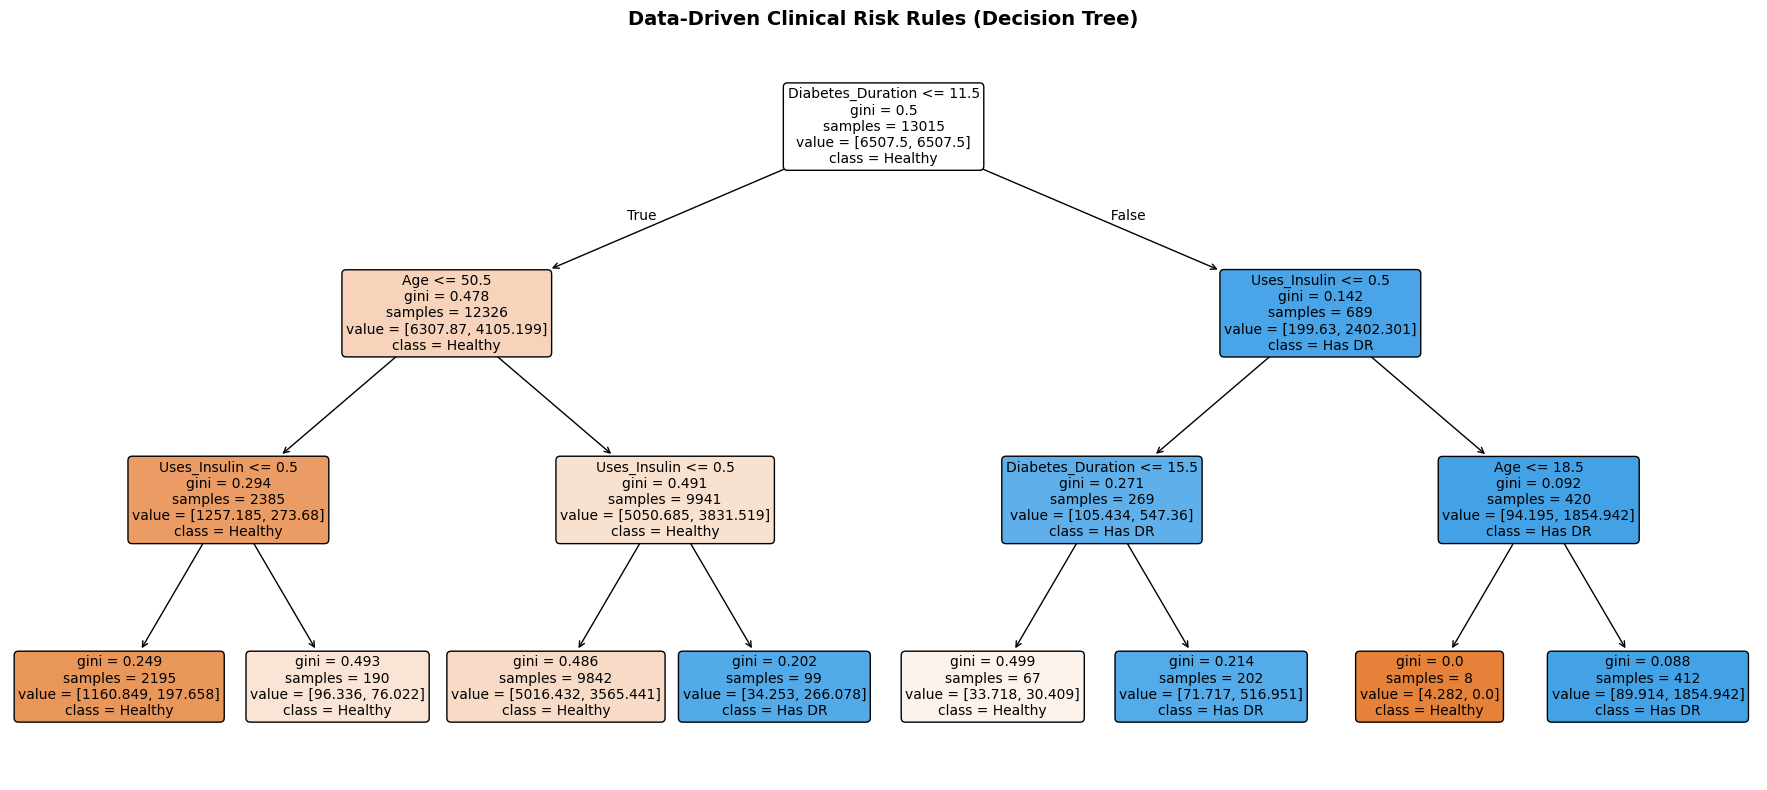

In [22]:
plt.figure(figsize=(18, 8))
plot_tree(tree_model, feature_names=list(X_imputed.columns),
          class_names=['Healthy', 'Has DR'], filled=True, rounded=True, fontsize=10)
plt.title('Data-Driven Clinical Risk Rules (Decision Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hybrid_decision_tree.png', dpi=150, bbox_inches='tight')
plt.show()

## 18. Comprehensive Summary

In [23]:
print('=' * 70)
print('HYBRID SYSTEM EVALUATION SUMMARY')
print('=' * 70)

print(f'''
Architecture: Category 3 Hybrid (CNN + Rule-Based Knowledge Base)
Test Set: {len(test_df)} images with clinical metadata

CNN CLASSIFICATION PERFORMANCE:
{'':>35} {'Method 1':>10} {'Method 2':>10}
  Accuracy:                      {(m1_preds==true_labels).mean():>10.4f} {(m2_preds==true_labels).mean():>10.4f}
  Balanced Accuracy:             {balanced_accuracy_score(true_labels, m1_preds):>10.4f} {balanced_accuracy_score(true_labels, m2_preds):>10.4f}
  F1 (weighted):                 {f1_score(true_labels, m1_preds, average='weighted'):>10.4f} {f1_score(true_labels, m2_preds, average='weighted'):>10.4f}
  F1 (macro):                    {f1_score(true_labels, m1_preds, average='macro'):>10.4f} {f1_score(true_labels, m2_preds, average='macro'):>10.4f}

HYBRID TRIAGE CONCORDANCE (vs Ground-Truth Triage):
  Action match:                  {m1_match:>10.1%} {m2_match:>10.1%}
  Urgency match:                 {m1_urg_match:>10.1%} {m2_urg_match:>10.1%}

CLINICAL SAFETY:
  Under-triage (dangerous):      {s1['under']/s1['total']:>10.1%} {s2['under']/s2['total']:>10.1%}
  Over-triage (safe):            {s1['over']/s1['total']:>10.1%} {s2['over']/s2['total']:>10.1%}

KNOWLEDGE BASE IMPACT:
  The KB rules modified triage actions beyond what the CNN grade alone
  would have produced, incorporating systemic risk factors (diabetes
  duration, insulin, hypertension), macular edema detection, and image
  quality flags to generate clinically interpretable recommendations.

  Triage actions: ANNUAL SCREENING, VIGILANCE SCREENING, LOCAL MONITORING,
                  ROUTINE REFERRAL, PRIORITY REFERRAL, URGENT REFERRAL
''')

HYBRID SYSTEM EVALUATION SUMMARY

Architecture: Category 3 Hybrid (CNN + Rule-Based Knowledge Base)
Test Set: 1619 images with clinical metadata

CNN CLASSIFICATION PERFORMANCE:
                                      Method 1   Method 2
  Accuracy:                          0.9351     0.9469
  Balanced Accuracy:                 0.6064     0.5957
  F1 (weighted):                     0.9385     0.9459
  F1 (macro):                        0.5610     0.5785

HYBRID TRIAGE CONCORDANCE (vs Ground-Truth Triage):
  Action match:                       95.3%      96.2%
  Urgency match:                      96.3%      96.7%

CLINICAL SAFETY:
  Under-triage (dangerous):            1.6%       2.0%
  Over-triage (safe):                  2.1%       1.4%

KNOWLEDGE BASE IMPACT:
  The KB rules modified triage actions beyond what the CNN grade alone
  would have produced, incorporating systemic risk factors (diabetes
  duration, insulin, hypertension), macular edema detection, and image
  quality flags to